# Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm

df = pd.read_csv("household_socioeconomic_dataset.csv")
df.head()

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
0,HH_001,63,17661,Secondary,4,Yes,Urban
1,HH_002,53,21118,Primary,6,No,Urban
2,HH_003,39,40884,Graduate,3,No,Rural
3,HH_004,67,10794,Graduate,6,No,Rural
4,HH_005,32,26082,Primary,3,No,Urban


# Identify Dataset

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Household_ID           200 non-null    str  
 1   Age_of_Household_Head  200 non-null    int64
 2   Household_Income       200 non-null    int64
 3   Education_Level        200 non-null    str  
 4   Family_Size            200 non-null    int64
 5   Owns_House             200 non-null    str  
 6   Urban_Rural            200 non-null    str  
dtypes: int64(3), str(4)
memory usage: 11.1 KB


# Central Tendency (Income & Age)

In [4]:
mean_income = df['Household_Income'].mean()
median_income = df['Household_Income'].median()
mode_income = df['Household_Income'].mode()[0]

mean_age = df['Age_of_Household_Head'].mean()
median_age = df['Age_of_Household_Head'].median()
mode_age = df['Age_of_Household_Head'].mode()[0]

print("Income - Mean:", mean_income)
print("Income - Median:", median_income)
print("Income - Mode:", mode_income)

print("Age - Mean:", mean_age)
print("Age - Median:", median_age)
print("Age - Mode:", mode_age)

Income - Mean: 25402.275
Income - Median: 21876.5
Income - Mode: 24698
Age - Mean: 47.885
Age - Median: 48.5
Age - Mode: 63


# Measures of Dispersion

In [5]:
income_range = df['Household_Income'].max() - df['Household_Income'].min()
income_variance = df['Household_Income'].var()
income_std = df['Household_Income'].std()

q1 = df['Household_Income'].quantile(0.25)
q3 = df['Household_Income'].quantile(0.75)
iqr = q3 - q1

print("Range:", income_range)
print("Variance:", income_variance)
print("Standard Deviation:", income_std)
print("IQR:", iqr)

Range: 94866
Variance: 195085646.01947236
Standard Deviation: 13967.306326542435
IQR: 14096.0


# Analysis 

# Histogram + KDE

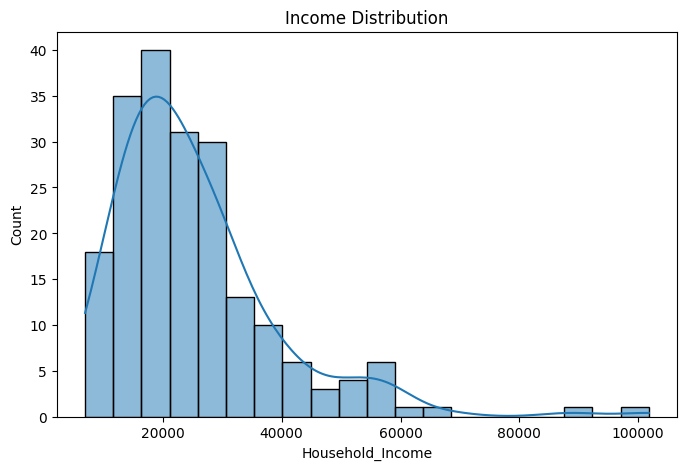

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Household_Income'], kde=True)
plt.title("Income Distribution")
plt.show()

# Fit Gaussian Curve

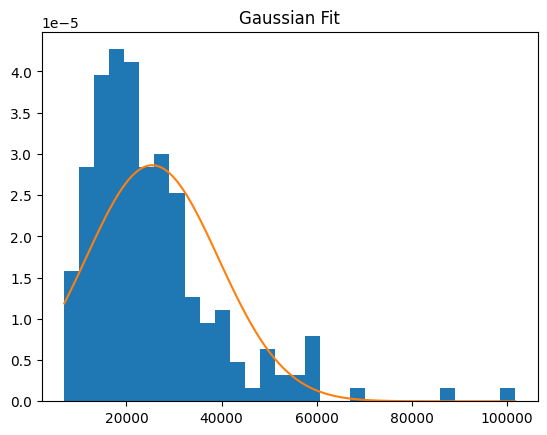

In [7]:
mu, sigma = norm.fit(df['Household_Income'])

x = np.linspace(df['Household_Income'].min(), df['Household_Income'].max(), 100)
p = norm.pdf(x, mu, sigma)

plt.hist(df['Household_Income'], bins=30, density=True)
plt.plot(x, p)
plt.title("Gaussian Fit")
plt.show()

# Boxplot

# Income by Education Level

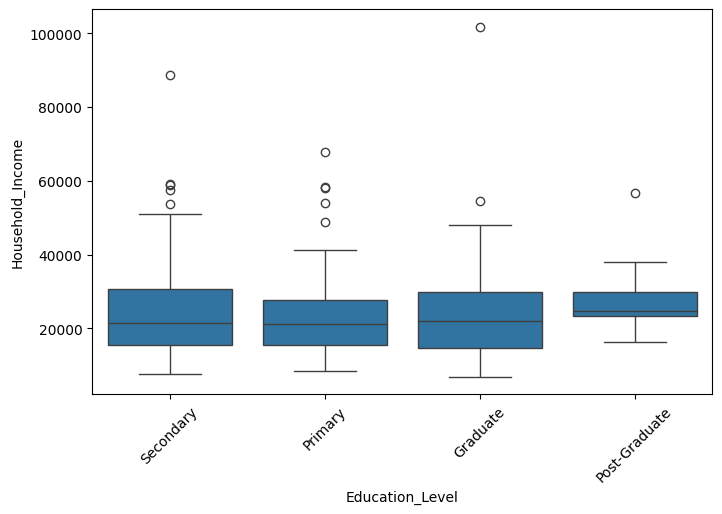

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Education_Level', y='Household_Income', data=df)
plt.xticks(rotation=45)
plt.show()

# Family Size by Education

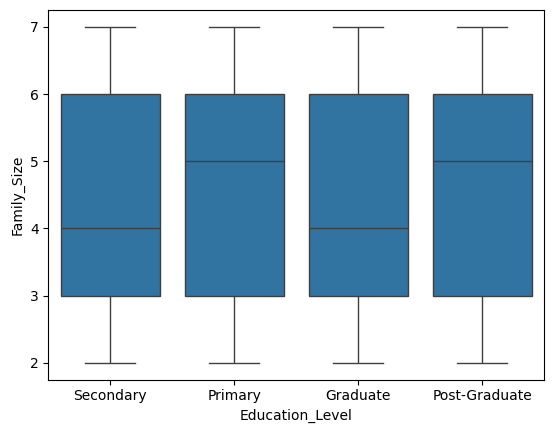

In [9]:
sns.boxplot(x='Education_Level', y='Family_Size', data=df)
plt.show()

# Age vs Income Distribution

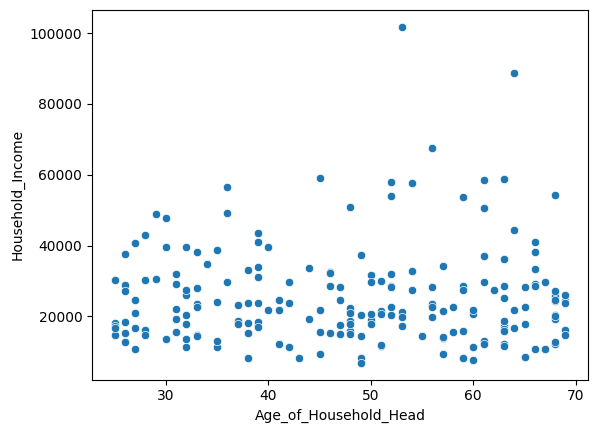

In [11]:
sns.scatterplot(x='Age_of_Household_Head', y='Household_Income', data=df)
plt.show()